# 08 · Customer value — historical, not CLV
Available: 2-year spend by category, purchase counts, AOV, enrolment date. Not available: transaction timestamps,
margins, churn events, acquisition channel. Therefore this notebook measures **historical customer value** only;
**predicted future value and CLV cannot be estimated defensibly** and are not reported.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:42:29] customer value


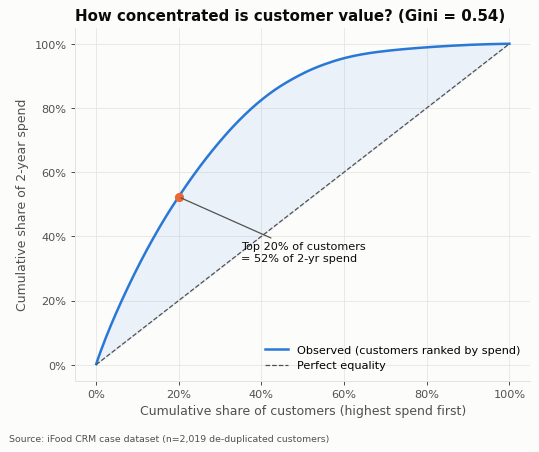

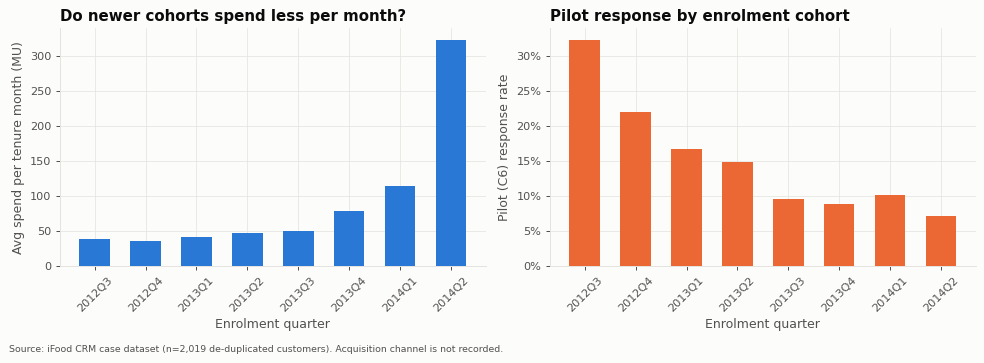

,value_decile,customers,min_spend,max_spend,revenue,avg_purchases,avg_aov,prior5_accept_rate,pilot_response,avg_income,revenue_share
0,1,202,1538,2524,368663,19.8,104,0.2188,0.4208,8.017e+04,0.3014
1,2,202,1173,1536,271966,20.23,69.53,0.1297,0.2574,7.296e+04,0.2224
2,3,202,915,1173,211183,19.45,56.99,0.06139,0.09901,6.898e+04,0.1727
3,4,202,636,914,157245,19.09,42,0.05347,0.1188,6.321e+04,0.1286
4,5,201,396,636,100097,15.18,32.89,0.04677,0.1294,5.396e+04,0.08184
5,6,202,201,396,58787,11.01,27.16,0.02772,0.09406,4.707e+04,0.04807
6,7,202,91,199,27437,6.916,21.01,0.01188,0.1436,3.966e+04,0.02243
7,8,202,55,91,14139,5.589,12.78,0.01881,0.1238,3.239e+04,0.01156
8,9,202,34,55,9109,4.723,9.931,0.01485,0.03465,3.113e+04,0.007448
9,10,202,5,34,4384,3.342,6.5,0.01287,0.03465,3.082e+04,0.003585


In [2]:
ctx = P.prepare('stage_value')
ctx = P.stage_value(ctx)
ctx['value_deciles']

In [3]:
ctx['category']

,category,revenue,share,pct_customers_buying
0,Wines,611512,0.5,0.9941
2,MeatProducts,338946,0.2771,0.9995
5,GoldProds,88143,0.07207,0.9718
3,FishProducts,75905,0.06206,0.8262
4,SweetProducts,55042,0.04501,0.8148
1,Fruits,53462,0.04371,0.8266


In [4]:
ctx['value_resp']

,value_tercile,responders,n,rate,ci_low,ci_high
0,Low,47,673,0.06984,0.05292,0.09163
1,Mid,80,673,0.1189,0.09656,0.1455
2,High,167,673,0.2481,0.217,0.2821


## 'Acquisition' — what the data can and cannot say

In [5]:
ctx['cohort']

,enrol_quarter,customers,avg_tenure_months,avg_total_spend,avg_spend_per_month,median_spend_per_month,pilot_response,prior5_accept_rate
0,2012Q3,195,21.97,834.9,38.11,31.84,0.3231,0.05949
1,2012Q4,241,19.46,686.2,35.25,26.69,0.2199,0.0556
2,2013Q1,281,16.46,680.3,41.45,32.47,0.1673,0.06263
3,2013Q2,249,13.49,643.4,47.56,35.22,0.1486,0.05542
4,2013Q3,273,10.47,519.6,50.27,26.04,0.09524,0.05861
5,2013Q4,272,7.532,574.8,77.84,43.1,0.08824,0.05147
6,2014Q1,257,4.367,491.5,113.7,36.03,0.1012,0.07237
7,2014Q2,251,1.535,473.9,322.9,90,0.07171,0.06135


> **Finding:** Newer enrolment cohorts show *higher* spend per tenure month (38 → 322 MU) although their 2-year spend is lower, and the most recent cohort (1.5 months tenure) has already spent 472 MU on average.
>
> **Business implication:** The '2-year spend' window is not aligned with enrolment (or the data are partly synthetic), so spend-per-tenure-month is not a valid value-rate metric and cohort comparisons of value are unreliable.
>
> **Recommended action:** Do not rank acquisition cohorts or channels by value; the acquisition channel is not recorded, so 'which channels acquire high-value customers' cannot be answered with this dataset.
>
> **Evidence:** Cohort table; value by enrolment quarter.
>
> **Assumption:** Enrolment date is correct.
>
> **Limitation:** Pilot response declines with newer cohorts (32 % → 7 %), which is an association with tenure, not an acquisition-channel effect.

> **Finding:** High-value tercile customers responded to the pilot at 24.8 % vs 7.0 % for the low tercile; the top value decile at 42 %.
>
> **Business implication:** Value and responsiveness overlap, so targeting responders also concentrates effort on valuable customers — but they are not the same list.
>
> **Recommended action:** Keep value as a second axis of the action matrix; see the response-vs-value trade-off in notebook 09.
>
> **Evidence:** Value terciles/deciles with Wilson CIs.
>
> **Assumption:** Historical spend proxies value.
>
> **Limitation:** Response revenue (11 MU) is the same for every customer in the case economics; value differences are not monetised in the profit calculation.